# 01 - Entity Extraction from Resumes

Fine-tunes a transformer NER model to pull structured fields out of free-text resumes:
name, skills, designation, employers, college, degree, graduation year, location, email.

**Corpus:** 200 annotated resumes, 3,206 entity spans, 10 labels (after dropping a 2-span
`UNKNOWN` class). Source: [`laxmimerit/CV-Parsing-using-Spacy-3`](https://github.com/laxmimerit/CV-Parsing-using-Spacy-3).
That repo ships no LICENSE, so the corpus is **not redistributed here** - the notebook
downloads it on first run.

**Model:** `distilroberta-base` + spaCy's transition-based NER head.

**Hardware:** trained on a 4 GB RTX 2050. That constraint drove two config choices,
documented in section 3.

**Result:** 0.46 exact-match F1 overall on a held-out test set - but that single number is
misleading, and section 5.1 shows why. `Name`, the one label with a consistent annotation
convention, reaches **0.95**. `Skills` reads 0.20 because the model finds the right entity
with the wrong boundaries (the corpus annotates whole 700-character sections). `Companies
worked at` reads 0.21 largely because the model finds real employers the corpus never
labelled. The corpus, not the model, sets most of that ceiling.

> Companion notebook: `02_relation_extraction.ipynb` covers relation extraction and the
> end-to-end pipeline. The two notebooks use **different corpora** - see section 7.

## 0. Setup

In [1]:
import os, sys
from pathlib import Path

# Repo-relative paths: works whether the kernel starts in notebooks/ or the repo root.
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC       = ROOT / "src"
RAW       = ROOT / "data" / "raw"
PROCESSED = ROOT / "data" / "processed"
CONFIGS   = ROOT / "configs"
MODELS    = ROOT / "models" / "ner_resume"
FIGURES   = ROOT / "figures"
REPORTS   = ROOT / "reports"
for d in (RAW, PROCESSED, MODELS.parent, FIGURES, REPORTS):
    d.mkdir(parents=True, exist_ok=True)

# --- CUDA shim, must run before spaCy touches CuPy -------------------------------
# On Windows, Python 3.8+ ignores PATH when resolving DLL dependencies of extension
# modules, so CuPy cannot find cudart64_12.dll and spacy.require_gpu() fails even
# though torch.cuda.is_available() is True. src/sitecustomize.py registers the CUDA
# runtime that ships inside the PyTorch wheel. Importing it fixes THIS process;
# putting src/ on PYTHONPATH makes `spacy train` subprocesses pick it up too, since
# add_dll_directory does not propagate to children.
sys.path.insert(0, str(SRC))
os.environ["PYTHONPATH"] = str(SRC) + os.pathsep + os.environ.get("PYTHONPATH", "")
import sitecustomize  # noqa: F401

In [2]:
import json, random, subprocess, collections, statistics

import spacy
from spacy.tokens import DocBin
from spacy.training import Example
import pandas as pd

SEED = 42
random.seed(SEED)

print("spaCy", spacy.__version__, "| python", sys.version.split()[0])
print("repo root:", ROOT.name)   # name only - keeps machine paths out of committed output

D:\Conda\envs\erx\Lib\site-packages\cupy\_environment.py:216: UserWarning: CUDA path could not be detected. Set CUDA_PATH environment variable if CuPy fails to load.
  warnings.warn(


spaCy 3.8.16 | python 3.11.15
repo root: entity_relation_extraction


In [3]:
# spacy.require_gpu() raises if CUDA/CuPy is unavailable, so probe and record the
# result - training falls back to CPU rather than dying if there is no GPU.
try:
    spacy.require_gpu()
    USE_GPU = True
    import torch
    print("GPU:", torch.cuda.get_device_name(0),
          f"| {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")
except Exception as e:
    USE_GPU = False
    print("No GPU available, falling back to CPU. Reason:", e)

GPU: NVIDIA GeForce RTX 2050 | 4.0 GB


## 1. Data

The corpus is fetched on first run and cached under `data/raw/` (gitignored).

In [4]:
import urllib.request

TRAIN_JSON = RAW / "train_data.json"
UPSTREAM = ("https://raw.githubusercontent.com/laxmimerit/"
            "CV-Parsing-using-Spacy-3/master/data/training/train_data.json")

if not TRAIN_JSON.exists():
    print("downloading corpus from upstream...")
    urllib.request.urlretrieve(UPSTREAM, TRAIN_JSON)

cv_data = json.loads(TRAIN_JSON.read_text(encoding="utf-8"))
n_spans = sum(len(a["entities"]) for _, a in cv_data)
print(f"{len(cv_data)} resumes, {n_spans} spans")
print()
print("example text (first 300 chars):")
print(cv_data[0][0][:300].replace("\n", " "))

200 resumes, 3206 spans

example text (first 300 chars):
Govardhana K Senior Software Engineer  Bengaluru, Karnataka, Karnataka - Email me on Indeed: indeed.com/r/Govardhana-K/ b2de315d95905b68  Total IT experience 5 Years 6 Months Cloud Lending Solutions INC 4 Month • Salesforce Developer Oracle 5 Years 2 Month • Core Java Developer Languages Core Java, 


### 1.1 Label distribution

In [5]:
counts = collections.Counter(lbl for _, a in cv_data for _, _, lbl in a["entities"])
dist = (pd.DataFrame(counts.most_common(), columns=["label", "spans"])
          .assign(pct=lambda d: (100 * d.spans / d.spans.sum()).round(1)))
dist

,label,spans,pct
0,Companies worked at,676,21.1
1,Designation,473,14.8
2,Skills,417,13.0
3,Location,381,11.9
4,College Name,291,9.1
5,Degree,268,8.4
6,Email Address,229,7.1
7,Graduation Year,222,6.9
8,Name,205,6.4
9,Years of Experience,42,1.3


`UNKNOWN` has only 2 spans - too few to learn or to score meaningfully, so it is dropped.
`Years of Experience` (42 spans) is kept but its metrics will be noisy; support counts are
reported alongside F1 in section 5 so the reader can judge which numbers to trust.

### 1.2 A corpus problem worth knowing about

span length - median 13.0, mean 30, max 2473
spans over 200 chars: 68 -> [('Skills', 68)]


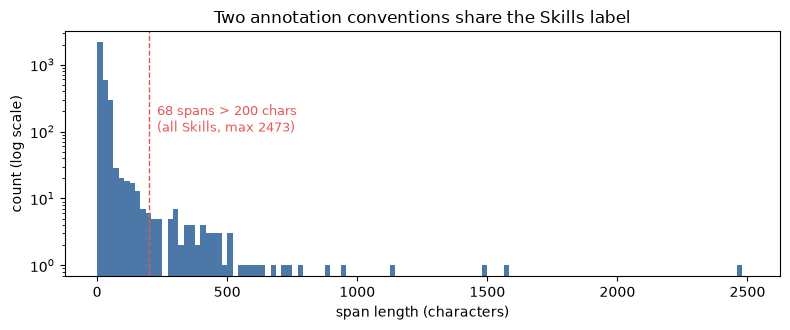

In [6]:
import matplotlib.pyplot as plt

lens = [(e[1] - e[0], e[2]) for _, a in cv_data for e in a["entities"]]
print(f"span length - median {statistics.median([l for l, _ in lens])}, "
      f"mean {statistics.mean([l for l, _ in lens]):.0f}, "
      f"max {max(l for l, _ in lens)}")

big = [(l, lab) for l, lab in lens if l > 200]
print(f"spans over 200 chars: {len(big)} ->",
      collections.Counter(lab for _, lab in big).most_common())

# Log y-axis: the long tail is only ~2% of spans, so on a linear axis it renders as
# zero height and the plot appears to show a single tight mode.
fig, ax = plt.subplots(figsize=(8, 3.4))
ax.hist([l for l, _ in lens], bins=120, range=(0, 2500), color="#4C78A8")
ax.set_yscale("log")
ax.axvline(200, color="#E45756", linestyle="--", linewidth=1)
ax.annotate(f"{len(big)} spans > 200 chars\n(all Skills, max {max(l for l, _ in lens)})",
            xy=(230, 100), color="#E45756", fontsize=9)
ax.set_xlabel("span length (characters)")
ax.set_ylabel("count (log scale)")
ax.set_title("Two annotation conventions share the Skills label")
fig.tight_layout()
fig.savefig(FIGURES / "span_lengths.png", dpi=150)
plt.show()

**Finding.** The median entity span is 13 characters, but 68 `Skills` spans run past 200
characters - the longest is 2,473. Those annotations cover an entire *skills section*, not
an individual skill. So `Skills` is really two different labelling conventions sharing one
name.

This is a property of the upstream corpus, not something to paper over. It is left in, and
the consequence shows up honestly as weak `Skills` performance in section 5.

## 2. Building the training data

Three things happen here.

**Overlapping spans.** The corpus contains annotations that overlap each other (the
whole-section `Skills` blobs typically swallow several `Companies worked at` mentions).
spaCy's NER cannot represent overlapping entities, so the first span to claim a *token*
wins and later overlapping spans are dropped. Token, not character, is the right unit -
see the note in `make_docbin` below.

**Token alignment.** Annotation offsets are character-level, but NER trains on *tokens*.
When an annotation starts or ends mid-token, `Doc.char_span` has to decide what to do -
and the choice is not cosmetic. It is measured below rather than assumed.

**A three-way split.** The original tutorial split the data train/test only and then used
the test set as spaCy's `dev` corpus - meaning early stopping selected the model on the
same data used to report the score. Here the split is train/dev/test: `dev` drives model
selection during training, and `test` is untouched until section 5.

### 2.1 Choosing an alignment mode

In [7]:
# How many annotations survive each alignment strategy?
_blank = spacy.blank("en")
rows = []
for mode in ("strict", "contract", "expand"):
    kept = lost = 0
    widened = []
    for text, a in cv_data:
        doc = _blank.make_doc(text)
        for s, e, lab in a["entities"]:
            if lab in {"UNKNOWN"} or s >= e:
                continue
            sp = doc.char_span(s, e, label=lab, alignment_mode=mode)
            if sp is None:
                lost += 1
            else:
                kept += 1
                widened.append((s - sp.start_char) + (sp.end_char - e))
    nz = [w for w in widened if w]
    rows.append({"mode": mode, "spans kept": kept, "spans lost": lost,
                 "spans widened": len(nz),
                 "median widening": statistics.median(nz) if nz else 0})
pd.DataFrame(rows).set_index("mode")

,spans kept,spans lost,spans widened,median widening
mode,,,,
strict,2929,274,0,0.0
contract,3104,99,175,-7.0
expand,3203,0,274,8.0


**Decision: `expand`.**

`strict` silently discards 274 annotations and `contract` 99 - and the loss is not spread
evenly. `Email Address` alone loses 53-55 of its 229 spans under either mode, roughly a
quarter of the label, because spaCy tokenizes an address like
`indeed.com/r/Govardhana-K/` as one token while the annotation cuts into it.

`expand` keeps every span by growing it out to the enclosing token boundaries. The price
is 274 spans widened by a median of 8 characters. Training on a slightly wide entity beats
not seeing the entity at all, so `expand` wins - but since the same rule is applied to the
test set, the reported scores are measured against these slightly widened gold spans.
That caveat is repeated in section 7.

One annotation is simply corrupt - `Graduation Year` with start 3884 and end 3880 - and is
dropped outright.

In [8]:
DROP_LABELS = {"UNKNOWN"}
ALIGNMENT = "expand"   # see 2.1

def make_docbin(data, nlp_blank, dropped_counter=None):
    """Convert (text, {entities: [...]}) pairs to a DocBin.

    Drops corrupt offsets, then resolves overlap at TOKEN granularity. Token, not
    character, is the level that matters: `expand` grows each span out to its enclosing
    token boundaries, so two annotations that are disjoint in characters can end up
    sharing a token, and `Doc.ents` rejects any token claimed by two spans.
    """
    db = DocBin()
    for text, annotations in data:
        doc = nlp_blank.make_doc(text)
        ents, claimed_tokens = [], set()
        for start, end, label in annotations["entities"]:
            if label in DROP_LABELS:
                continue
            if start >= end or end > len(text):      # corrupt offsets
                if dropped_counter is not None:
                    dropped_counter[label + " (corrupt offsets)"] += 1
                continue
            span = doc.char_span(start, end, label=label, alignment_mode=ALIGNMENT)
            if span is None:                          # unreachable with expand; kept honest
                if dropped_counter is not None:
                    dropped_counter[label + " (misaligned)"] += 1
                continue
            token_range = range(span.start, span.end)
            if any(i in claimed_tokens for i in token_range):
                if dropped_counter is not None:
                    dropped_counter[label + " (overlap)"] += 1
                continue
            claimed_tokens.update(token_range)
            ents.append(span)
        doc.ents = ents
        db.add(doc)
    return db

In [9]:
from sklearn.model_selection import train_test_split

train, temp = train_test_split(cv_data, test_size=0.30, random_state=SEED)
dev,   test = train_test_split(temp,    test_size=0.50, random_state=SEED)
print(f"train {len(train)} | dev {len(dev)} | test {len(test)} resumes")

nlp_blank = spacy.blank("en")
dropped = collections.Counter()
for split_name, split_data in (("train", train), ("dev", dev), ("test", test)):
    db = make_docbin(split_data, nlp_blank, dropped)
    db.to_disk(PROCESSED / f"resume_{split_name}.spacy")

print("\nspans dropped:")
for k, v in dropped.most_common():
    print(f"  {k:32s} {v}")

train 140 | dev 30 | test 30 resumes



spans dropped:
  Skills (overlap)                 35
  Designation (overlap)            27
  Degree (overlap)                 20
  Companies worked at (overlap)    18
  College Name (overlap)           6
  Location (overlap)               3
  Email Address (overlap)          2
  Graduation Year (corrupt offsets) 1
  Graduation Year (overlap)        1
  Name (overlap)                   1


## 3. Config

Two changes to the spaCy quickstart config, both forced by the 4 GB RTX 2050:

| setting | quickstart | here | why |
|---|---|---|---|
| transformer | `roberta-base` (125M) | `distilroberta-base` (82M) | roberta-base + Adam states is ~2 GB before activations; OOMs at this batch size |
| `[training.batcher] size` | 2000 | 500 | smaller batches fit in VRAM; `accumulate_gradient = 3` preserves the effective batch |

The tradeoff is real: distilroberta gives up some headroom in exchange for fitting the
hardware. It is recorded here rather than buried.

In [10]:
BASE_CFG = CONFIGS / "base_ner.cfg"
FULL_CFG = CONFIGS / "ner.cfg"

subprocess.run([sys.executable, "-m", "spacy", "init", "fill-config",
                str(BASE_CFG), str(FULL_CFG)], check=True)
print("wrote", FULL_CFG.relative_to(ROOT))

wrote configs\ner.cfg


## 4. Training

In [11]:
# Training takes ~30 min on the RTX 2050. Re-running the notebook reuses the existing
# model unless you flip this.
RETRAIN = False

if (MODELS / "model-best").exists() and not RETRAIN:
    print("model-best already exists, skipping training (set RETRAIN = True to force)")
else:
    cmd = [sys.executable, "-m", "spacy", "train", str(FULL_CFG),
           "--output", str(MODELS),
           "--paths.train", str(PROCESSED / "resume_train.spacy"),
           "--paths.dev",   str(PROCESSED / "resume_dev.spacy")]
    if USE_GPU:
        cmd += ["--gpu-id", "0"]
    print(" ".join(cmd), "\n")
    subprocess.run(cmd, check=True)

model-best already exists, skipping training (set RETRAIN = True to force)


## 5. Evaluation

Scored on `resume_test.spacy`, which was used neither for training nor for early stopping.

In [12]:
nlp = spacy.load(MODELS / "model-best")

test_db = DocBin().from_disk(PROCESSED / "resume_test.spacy")
examples = [Example(nlp(ref.text), ref) for ref in test_db.get_docs(nlp.vocab)]
scores = nlp.evaluate(examples)

support = collections.Counter(ent.label_ for ex in examples for ent in ex.reference.ents)

per_type = (pd.DataFrame(scores["ents_per_type"]).T
              .rename(columns={"p": "precision", "r": "recall", "f": "f1"})
              .assign(support=lambda d: d.index.map(support))
              .sort_values("f1", ascending=False))
per_type.loc["** OVERALL **"] = [scores["ents_p"], scores["ents_r"],
                                 scores["ents_f"], sum(support.values())]
per_type.round(3)

D:\Conda\envs\erx\Lib\site-packages\spacy_transformers\layers\hf_shim.py:124: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  self._model.load_state_dict(torch.load(filelike, 

,precision,recall,f1,support
Name,0.935,0.967,0.951,30.0
Email Address,0.561,0.793,0.657,29.0
Degree,0.618,0.583,0.600,36.0
Location,0.667,0.522,0.585,69.0
Designation,0.567,0.594,0.580,64.0
College Name,0.564,0.524,0.543,42.0
Graduation Year,0.467,0.226,0.304,31.0
Companies worked at,0.223,0.189,0.205,111.0
Skills,0.344,0.141,0.200,78.0
Years of Experience,0.000,0.000,0.000,4.0


In [13]:
out = REPORTS / "ner_resume_metrics.md"
out.write_text(
    "# Resume NER - held-out test metrics\n\n"
    f"distilroberta-base | {len(test)} test resumes | "
    f"{sum(support.values())} gold spans\n\n"
    + per_type.round(3).to_markdown() + "\n",
    encoding="utf-8")
print(per_type.round(3).to_markdown())

|                     |   precision |   recall |    f1 |   support |
|:--------------------|------------:|---------:|------:|----------:|
| Name                |       0.935 |    0.967 | 0.951 |        30 |
| Email Address       |       0.561 |    0.793 | 0.657 |        29 |
| Degree              |       0.618 |    0.583 | 0.6   |        36 |
| Location            |       0.667 |    0.522 | 0.585 |        69 |
| Designation         |       0.567 |    0.594 | 0.58  |        64 |
| College Name        |       0.564 |    0.524 | 0.543 |        42 |
| Graduation Year     |       0.467 |    0.226 | 0.304 |        31 |
| Companies worked at |       0.223 |    0.189 | 0.205 |       111 |
| Skills              |       0.344 |    0.141 | 0.2   |        78 |
| Years of Experience |       0     |    0     | 0     |         4 |
| ** OVERALL **       |       0.509 |    0.421 | 0.461 |       494 |


### 5.1 Where do the errors actually come from?

An overall F1 of 0.46 invites the question of whether the model is bad or the corpus is.
Splitting every gold span three ways answers it: matched exactly, found with the **right
label but the wrong boundaries**, or missed completely.

In [14]:
exact, loose, missed = (collections.Counter() for _ in range(3))
for ex in examples:
    gold, pred = ex.reference, ex.predicted
    pred_spans = [(e.start_char, e.end_char, e.label_) for e in pred.ents]
    for e in gold.ents:
        if (e.start_char, e.end_char, e.label_) in pred_spans:
            exact[e.label_] += 1
        elif any(lab == e.label_ and not (pe <= e.start_char or ps >= e.end_char)
                 for ps, pe, lab in pred_spans):
            loose[e.label_] += 1
        else:
            missed[e.label_] += 1

breakdown = pd.DataFrame({
    "exact": pd.Series(exact),
    "right label, wrong bounds": pd.Series(loose),
    "missed": pd.Series(missed),
}).fillna(0).astype(int)
breakdown["relaxed recall"] = ((breakdown["exact"] + breakdown["right label, wrong bounds"])
                               / breakdown.sum(axis=1)).round(3)
breakdown.sort_values("relaxed recall", ascending=False)

,exact,"right label, wrong bounds",missed,relaxed recall
Name,29,0,1,0.967
Email Address,23,2,4,0.862
Designation,38,8,18,0.719
College Name,22,7,13,0.690
Degree,21,3,12,0.667
Skills,11,37,30,0.615
Location,36,3,30,0.565
Companies worked at,21,12,78,0.297
Graduation Year,7,0,24,0.226
Years of Experience,0,0,4,0.000


**Two different failures, not one.**

`Skills` is a *boundary* failure: only 11 of 78 gold spans match exactly, but 37 more are
found with the right label and the wrong span. The model spots the individual skill; the
gold annotation is a 737-character section blob (section 1.2). Under exact-match scoring
that counts as a total miss, which is why `Skills` F1 reads 0.20.

`Companies worked at` is an *annotation-completeness* failure. 78 of 111 gold spans are
scored as missed, yet inspecting the predictions shows the model finding real employers
the corpus simply never labelled - it predicts `Microsoft`, `Microsoft GPS` and
`IBM RESEARCH` on a resume whose gold annotation lists `Microsoft GPS` twice and nothing
else, and finds `Microsoft` on a resume with no company annotations at all. Those correct
predictions are counted as false positives.

So the headline 0.46 is a floor set substantially by the corpus, not a clean read on the
model. `Name` - the one label with an unambiguous, consistently applied convention -
scores 0.95. That contrast is the real result of this notebook.

## 6. Qualitative check

In [15]:
from spacy import displacy

sample = test[0][0][:1500]
doc = nlp(sample)
html = displacy.render(doc, style="ent", jupyter=False)
(FIGURES / "ner_sample.html").write_text(html, encoding="utf-8")
displacy.render(doc, style="ent", jupyter=True)

## 7. Limitations

- **200 resumes is a small corpus.** The test split is 30 documents. Per-label F1 for
  low-support labels (`Years of Experience` has 4 gold spans in the test set) is noise, not
  signal - 0.00 there means "untestable", not "learned nothing". Support counts are in the
  table for exactly this reason.
- **The corpus annotation is incomplete**, which caps the achievable score. `Companies
  worked at` predictions that look correct on inspection are scored as false positives
  because the gold annotation omits them (section 5.1). Reported precision is therefore a
  lower bound on real precision.
- **`Skills` mixes two annotation conventions** (individual skills and whole sections, see
  section 1.2), so it fails on boundaries rather than on detection. A relaxed-match score
  is reported alongside exact match in 5.1 for this reason.
- **Exact-match scoring throughout.** That is the strict and standard choice, but for a
  downstream resume-parsing product, partial matches are often usable, and the relaxed
  numbers in 5.1 would be the more relevant target.
- **Overlapping spans are dropped**, because spaCy's NER cannot represent them.
  A span categorizer (`spancat`) handles overlap and is the natural next step.
- **Gold spans are token-aligned with `expand`** (section 2.1), which widens 274 spans by
  a median of 8 characters. Scores are therefore measured against those widened spans, so
  they are not directly comparable to a run that used `strict` or `contract` alignment.
  The alternative was discarding up to a quarter of the `Email Address` label.
- **`distilroberta-base`, not `roberta-base`**, to fit 4 GB of VRAM. Expect a point or two
  of F1 left on the table on larger hardware.
- **Different corpus from notebook 02.** This notebook uses resumes; `02` uses job
  descriptions with a different entity schema. They are two complementary extraction tasks
  over hiring-domain text, not two stages of one chain. `02` builds its own end-to-end
  chain internally.